# Baseline Fraud Detection Model

This notebook establishes an interpretable Logistic Regression, Random Forest and XGBoost baseline for customer-behavioural fraud detection. It uses the engineered transaction features, a stratified holdout split, and train-only feature scaling. The resulting metrics and saved artifacts provide a reproducible reference point for later model iterations.

> **Evaluation note:** Fraud is a rare event in this dataset, so fraud-class precision, recall, F1, and PR-AUC are more informative than accuracy alone.

In [18]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
PALETTE = {0: "#4C78A8", 1: "#E45756"}

df = pd.read_csv("../data/processed/transactions_behavioral.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (283726, 39)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,Amount,Class,Hour,Time_Period,Amount_Log,Amount_Category,Transaction_Time,Transactions_Last_1H,Transactions_Last_24H,Amount_ZScore
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,149.62,0,0,Night,5.014760,Medium,0 days 00:00:00,0.0,0.0,0.244199
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,2.69,0,0,Night,1.305626,Low,0 days 00:00:00,0.0,0.0,-0.342583
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,378.66,0,0,Night,5.939276,High,0 days 00:00:01,2.0,2.0,1.158898
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,123.50,0,0,Night,4.824306,Medium,0 days 00:00:01,2.0,2.0,0.139886
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,69.99,0,0,Night,4.262539,Medium,0 days 00:00:02,4.0,4.0,-0.073813


## 1. Dataset overview and class balance

We first confirm the available features and inspect the target distribution. This check is important because the severe class imbalance determines how the baseline should be interpreted.

In [19]:
pd.Series(df.columns, name="Available features")

0                      Time
1                        V1
2                        V2
3                        V3
4                        V4
5                        V5
6                        V6
7                        V7
8                        V8
9                        V9
10                      V10
11                      V11
12                      V12
13                      V13
14                      V14
15                      V15
16                      V16
17                      V17
18                      V18
19                      V19
20                      V20
21                      V21
22                      V22
23                      V23
24                      V24
25                      V25
26                      V26
27                      V27
28                      V28
29                   Amount
30                    Class
31                     Hour
32              Time_Period
33               Amount_Log
34          Amount_Category
35         Transacti

Class
Legitimate    283253
Fraud            473
Name: Transactions, dtype: int64

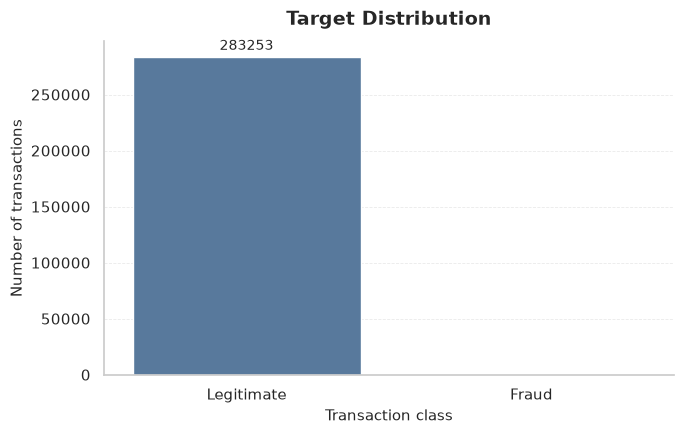

In [20]:
class_counts = df["Class"].value_counts().sort_index()
class_labels = {0: "Legitimate", 1: "Fraud"}

display(class_counts.rename(index=class_labels).rename("Transactions"))

fig, ax = plt.subplots(figsize=(7, 4.5))
sns.barplot(
    x=[class_labels[label] for label in class_counts.index],
    y=class_counts.values,
    hue=class_counts.index,
    palette=PALETTE,
    legend=False,
    ax=ax,
)
ax.set_title("Target Distribution", fontsize=14, weight="bold", pad=12)
ax.set_xlabel("Transaction class", fontsize=11)
ax.set_ylabel("Number of transactions", fontsize=11)
ax.bar_label(ax.containers[0], fmt="%d", padding=3, fontsize=10)
ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.4)
ax.set_axisbelow(True)
sns.despine(left=False, bottom=False)
plt.tight_layout()
plt.show()

## 2. Feature matrix preparation

`Class` is retained as the target. Non-numeric derived fields and the raw transaction-time representation are excluded so that the baseline receives only numeric model inputs. The remaining checks verify that the feature matrix is ready for scikit-learn.

In [21]:
X = df.drop(columns=[
    "Class",
    "Time_Period",
    "Amount_Category",
    "Amount_ZScore",
    "Transaction_Time"  # drop non-numeric timedelta strings
])

y = df["Class"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (283726, 34)
y shape: (283726,)


## 3. Stratified split and scaling

The holdout split preserves the fraud rate in both partitions. `StandardScaler` is fit only on the training data, preventing test-set information from influencing the model preparation.

In [22]:
X.dtypes

Time                     float64
V1                       float64
V2                       float64
V3                       float64
V4                       float64
V5                       float64
V6                       float64
V7                       float64
V8                       float64
V9                       float64
V10                      float64
V11                      float64
V12                      float64
V13                      float64
V14                      float64
V15                      float64
V16                      float64
V17                      float64
V18                      float64
V19                      float64
V20                      float64
V21                      float64
V22                      float64
V23                      float64
V24                      float64
V25                      float64
V26                      float64
V27                      float64
V28                      float64
Amount                   float64
Hour      

In [23]:
X.select_dtypes(include=["object", "str"]).columns

Index([], dtype='str')

In [24]:
print(X.columns.tolist())

['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Hour', 'Amount_Log', 'Transactions_Last_1H', 'Transactions_Last_24H']


In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Training set: {X_train.shape[0]:,} rows")
print(f"Test set:     {X_test.shape[0]:,} rows")
print(f"Training fraud rate: {y_train.mean():.3%}")
print(f"Test fraud rate:     {y_test.mean():.3%}")

Training set: 226,980 rows
Test set:     56,746 rows
Training fraud rate: 0.167%
Test fraud rate:     0.167%


The duplicate split cell from the original notebook has been removed; the single split above is the reproducible source for every downstream step.

In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 4. Logistic Regression baseline

Logistic Regression is used as a transparent first benchmark. It produces both class predictions at the default threshold and probabilities for threshold-independent evaluation.

In [27]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(
    X_train_scaled,
    y_train
)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [28]:
y_pred = logistic_model.predict(X_test_scaled)

print(y_pred[:20])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [29]:
y_proba = logistic_model.predict_proba(X_test_scaled)[:, 1]

print(y_proba[:20])

[2.46852745e-04 2.48136363e-04 1.50075840e-05 1.13149565e-04
 1.05771360e-03 3.20870161e-04 2.85469651e-05 7.30436301e-05
 7.94345431e-05 1.56901785e-04 1.06829477e-04 3.39505023e-04
 8.33221742e-04 2.18621952e-04 2.18463653e-04 9.24801978e-05
 3.62528581e-03 3.38665429e-05 5.04872130e-04 1.92697956e-05]


## 5. Evaluation

The following views evaluate default-threshold predictions and probability ranking. For an imbalanced fraud problem, pay particular attention to fraud recall (missed fraud), precision (alert quality), F1, and the precision-recall curve.

In [30]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.85      0.59      0.70        95

    accuracy                           1.00     56746
   macro avg       0.92      0.79      0.85     56746
weighted avg       1.00      1.00      1.00     56746



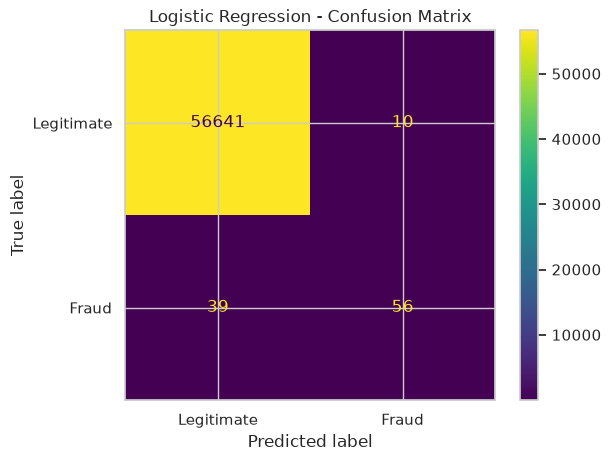

In [34]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Legitimate", "Fraud"]
)

disp.plot()

plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [35]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Fraud precision: {precision:.3f}")
print(f"Fraud recall:    {recall:.3f}")
print(f"Fraud F1 score:  {f1:.3f}")

Fraud precision: 0.848
Fraud recall:    0.589
Fraud F1 score:  0.696


PR-AUC: 0.698


/home/tonoy-sen/Desktop/pro/BehaviorGuard/.venv/lib/python3.12/site-packages/sklearn/utils/_plotting.py:193: FutureWarning: `**kwargs` is deprecated and will be removed in 1.11. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


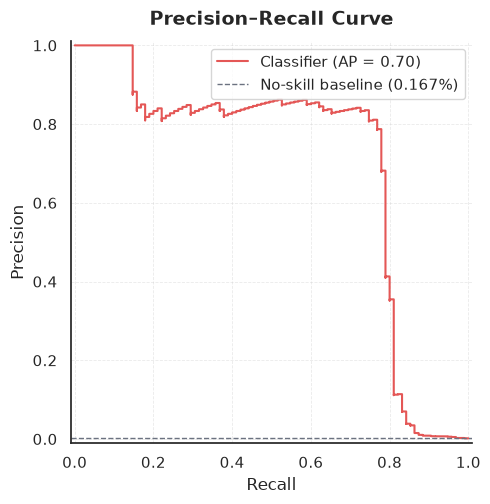

In [39]:
from sklearn.metrics import average_precision_score, PrecisionRecallDisplay
import warnings

pr_auc = average_precision_score(
    y_test,
    y_proba,
)

print(f"PR-AUC: {pr_auc:.3f}")

fig, ax = plt.subplots(figsize=(8, 5.2))
PrecisionRecallDisplay.from_predictions(y_test, y_proba, ax=ax, color="#E45756")
ax.axhline(
    y=y_test.mean(),
    color="#6B7280",
    linestyle="--",
    linewidth=1,
    label=f"No-skill baseline ({y_test.mean():.3%})",
)
ax.set_title("Precision–Recall Curve", fontsize=14, weight="bold", pad=12)
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend(loc="upper right")
ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.4)
ax.set_axisbelow(True)
sns.despine()
fig.tight_layout()
plt.show()

In [47]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(
    y_test,
    y_proba
)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.9545014767240603


In [48]:
baseline_results = {
    "Model": "Logistic Regression",
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1,
    "PR-AUC": pr_auc,
    "ROC-AUC": roc_auc
}

baseline_results

{'Model': 'Logistic Regression',
 'Precision': 0.8484848484848485,
 'Recall': 0.5894736842105263,
 'F1 Score': 0.6956521739130435,
 'PR-AUC': 0.6979573556412398,
 'ROC-AUC': 0.9545014767240603}

In [49]:
results_df = pd.DataFrame([baseline_results])

results_df.style.format({
    "Precision": "{:.3f}",
    "Recall": "{:.3f}",
    "F1 Score": "{:.3f}",
    "PR-AUC": "{:.3f}",
    "ROC-AUC": "{:.3f}"
}).hide(axis="index")

Model,Precision,Recall,F1 Score,PR-AUC,ROC-AUC
Logistic Regression,0.848,0.589,0.696,0.698,0.955


## 6. Persist baseline artifacts

Both the fitted model and the scaler are saved. Using the paired scaler at inference time ensures incoming transactions receive the same feature transformation as the training data.

In [51]:
import joblib
from pathlib import Path

model_dir = Path("../models")
model_dir.mkdir(parents=True, exist_ok=True)

# Keep the trained estimator and its fitted scaler together for reproducible inference.
joblib.dump(logistic_model, model_dir / "logistic_baseline.pkl")
joblib.dump(scaler, model_dir / "scaler.pkl")

print(f"Saved baseline model and scaler to {model_dir.resolve()}")

Saved baseline model and scaler to /home/tonoy-sen/Desktop/pro/BehaviorGuard/BehaviorGuard — Customer Behavioral Profiling for Credit Card Fraud Detection/models


##Random Forest

In [52]:
from sklearn.ensemble import RandomForestClassifier

In [53]:
random_forest = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

In [54]:
random_forest.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_feat

In [56]:
rf_pred = random_forest.predict(X_test)

rf_proba = random_forest.predict_proba(X_test)[:, 1]

print("Predicted fraud:", (rf_pred == 1).sum())

Predicted fraud: 91


In [57]:
from sklearn.metrics import classification_report

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.79      0.76      0.77        95

    accuracy                           1.00     56746
   macro avg       0.90      0.88      0.89     56746
weighted avg       1.00      1.00      1.00     56746



In [58]:
from sklearn.metrics import average_precision_score, roc_auc_score

rf_pr_auc = average_precision_score(
    y_test,
    rf_proba
)

rf_roc_auc = roc_auc_score(
    y_test,
    rf_proba
)

print("Random Forest PR-AUC:", rf_pr_auc)
print("Random Forest ROC-AUC:", rf_roc_auc)

Random Forest PR-AUC: 0.7664872152748958
Random Forest ROC-AUC: 0.979502568357134


In [59]:
comparison = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "PR-AUC": pr_auc,
        "ROC-AUC": roc_auc
    },
    {
        "Model": "Random Forest",
        "Precision": precision_score(y_test, rf_pred),
        "Recall": recall_score(y_test, rf_pred),
        "F1": f1_score(y_test, rf_pred),
        "PR-AUC": rf_pr_auc,
        "ROC-AUC": rf_roc_auc
    }
])

comparison

,Model,Precision,Recall,F1,PR-AUC,ROC-AUC
0,Logistic Regression,0.848485,0.589474,0.695652,0.697957,0.954501
1,Random Forest,0.791209,0.757895,0.774194,0.766487,0.979503


In [62]:
import joblib

joblib.dump(random_forest, "../models/random_forest.pkl")

print("Random Forest model saved successfully!")

Random Forest model saved successfully!
